**Code Explanation:**
**Path Setup**: Appends the `code` directory to the Python path.

In [1]:
import sys
import os
# Add the sibling 'code' directory to the Python path
sys.path.append(os.path.abspath('../code'))


# Experiment 05 - Removal-rate phase diagram in the (D2, D3) plane

This notebook adds a numerical experiment focused on the main modelling point of the paper: the removal rates `D1`, `D2`, and `D3` are distinct. Because the removal rates differ across species, the usual conservation law for simpler chemostat models fails, and the full four-dimensional system must be studied.

Here we fix `D1` and sweep the removal rates of predator 1 and predator 2:

- `D2`: removal rate of the first predator `y`.
- `D3`: removal rate of the second predator `z`.

The output is a 2D phase diagram showing how changing `(D2, D3)` changes the long-term ecological regime.

## Model

We use the corrected biological form used throughout the notebooks:

$$
\begin{aligned}
\frac{dS}{dt} &= 1 - S - f_1(S)x,\\
\frac{dx}{dt} &= x(f_1(S)-D_1) - f_2(x)y,\\
\frac{dy}{dt} &= y(f_2(x)-D_2) - f_3(y)z,\\
\frac{dz}{dt} &= z(f_3(y)-D_3).
\end{aligned}
$$

The response functions are Monod functions:

$$
f_1(S)=\frac{a_1S}{K_1+S},\quad
f_2(x)=\frac{a_2x}{K_2+x},\quad
f_3(y)=\frac{a_3y}{K_3+y}.
$$


**Code Explanation:**
**Imports & Classification Setup**: Imports the `simulate_and_classify` utility to automatically categorize the system's long-term behavior. Defines color maps and labels for five distinct dynamical regimes (Washout, Prey only, $P_2$ boundary, Stable $P_3$, Oscillatory coexistence).

In [2]:
from simulation import solve_model
from classification import classify_regime, simulate_and_classify

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from scipy.integrate import solve_ivp
from model import ChemostatModel

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "figures" / "removal_rate_phase_diagram"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved: {path}")

REGIME_LABELS = {
    0: "Washout",
    1: "Prey only",
    2: "P2 boundary",
    3: "Stable P3",
    4: "Oscillatory coexistence",
}

REGIME_COLORS = ["#d9d9d9", "#80b1d3", "#8dd3c7", "#b3de69", "#fb8072"]
cmap = ListedColormap(REGIME_COLORS)
norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

## Regime classifier

For each point `(D2, D3)`, the ODE is solved and the transient part is discarded. The long-run mean and amplitude are then used to classify the ecological state:

- `0`: washout `P0`, if `x, y, z` are near zero.
- `1`: prey-only `P1`, if `x` remains positive but `y` and `z` go to zero.
- `2`: boundary coexistence `P2`, if `x` and `y` remain positive but `z` goes to zero.
- `3`: stable full coexistence `P3`, if `x, y, z` remain positive and oscillation amplitude is small.
- `4`: oscillatory coexistence, if `x, y, z` remain positive and long-run oscillation amplitude is large.

Near extinction boundaries, one species may decay slowly. The classifier uses both mean and amplitude to avoid over-interpreting small numerical residues.

## Parameter sweep

The grid below is intentionally moderate so the notebook can run on a normal laptop. Increase `GRID_N` for smoother boundaries if more computation time is available.


**Code Explanation:**
**Grid Simulation**: Sets up a 2D grid spanning different values of $D_2$ and $D_3$. It systematically simulates the model at each grid point and classifies the resulting asymptotic behavior into one of the five defined regimes.

In [3]:
base_params = dict(
    a1=3.2,
    b1=0.45,
    a2=2.0,
    b2=0.25,
    a3=1.4,
    b3=0.25,
    D1=0.45,
)

GRID_N = 50
D2_values = np.linspace(0.15, 2.30, GRID_N)
D3_values = np.linspace(0.08, 1.20, GRID_N)

regime_grid = np.zeros((len(D3_values), len(D2_values)), dtype=int)
mean_grid = np.zeros((len(D3_values), len(D2_values), 4))
amp_grid = np.zeros((len(D3_values), len(D2_values), 4))
bio_amp_grid = np.zeros((len(D3_values), len(D2_values)))

for i, D3 in enumerate(D3_values):
    for j, D2 in enumerate(D2_values):
        regime, means, amps, bio_amp = simulate_and_classify(D2, D3, base_params)
        regime_grid[i, j] = regime
        mean_grid[i, j] = means
        amp_grid[i, j] = amps
        bio_amp_grid[i, j] = bio_amp
    if (i + 1) % 10 == 0 or i == 0:
        print(f"completed row {i+1}/{len(D3_values)}")

unique, counts = np.unique(regime_grid, return_counts=True)
print("Regime counts:")
for cls, count in zip(unique, counts):
    print(f"  {cls}: {REGIME_LABELS[cls]} -> {count}")

completed row 1/50
completed row 10/50
completed row 20/50
completed row 30/50
completed row 40/50
completed row 50/50
Regime counts:
  0: Washout -> 193
  1: Prey only -> 616
  2: P2 boundary -> 972
  3: Stable P3 -> 65
  4: Oscillatory coexistence -> 654


## Heatmap: long-term regime as D2 and D3 vary


**Code Explanation:**
**Phase Diagram Heatmap**: Generates a colored heatmap of the 2D classification grid in the $(D_2, D_3)$ plane. This provides a macroscopic view of how the varying removal rates shift the system between washout, boundary survival, stable coexistence, and periodic oscillations.

saved: /home/nguyen-tri/NguyenTri/Code/PrjMM/experiments/figures/removal_rate_phase_diagram/removal_rate_phase_diagram_heatmap.png


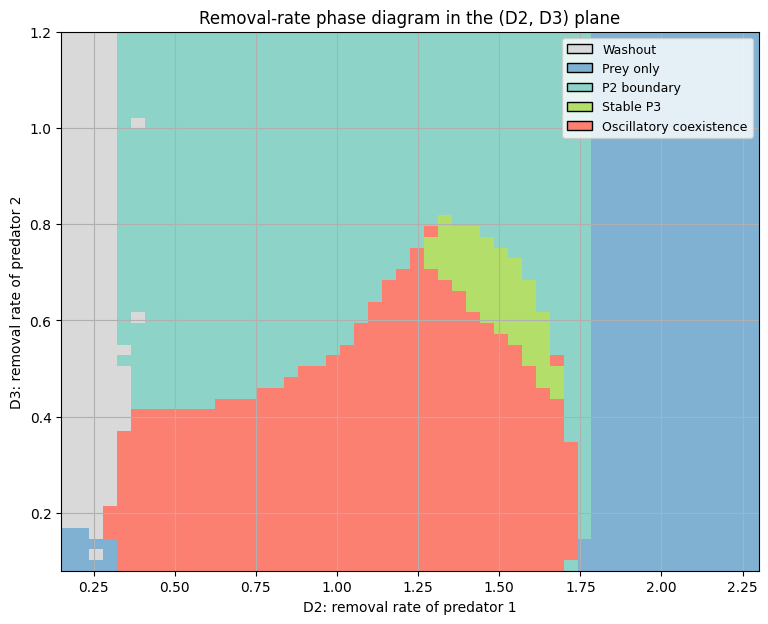

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    regime_grid,
    origin="lower",
    extent=[D2_values.min(), D2_values.max(), D3_values.min(), D3_values.max()],
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)
ax.set_xlabel("D2: removal rate of predator 1")
ax.set_ylabel("D3: removal rate of predator 2")
ax.set_title("Removal-rate phase diagram in the (D2, D3) plane")
legend_handles = [Patch(facecolor=REGIME_COLORS[k], edgecolor="black", label=REGIME_LABELS[k]) for k in range(5)]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=9)
savefig("removal_rate_phase_diagram_heatmap.png")
plt.show()

## Representative time series

The next cell selects representative parameter points from the heatmap and plots the full trajectories. The target examples are:

- one prey-only case,
- one `P2` boundary coexistence case,
- one stable `P3` case,
- one oscillatory coexistence case, if found.


**Code Explanation:**
**Representative Points Selection**: Programmatically searches the grid to extract a representative interior $(D_2, D_3)$ coordinate for each of the four non-trivial regimes (excluding total washout) for detailed analysis.

In [5]:
def nearest_grid_point_for_regime(target):
    positions = np.argwhere(regime_grid == target)
    if len(positions) == 0:
        return None
    # Prefer an interior-looking point, away from noisy boundaries, by taking the median index.
    pos = positions[len(positions) // 2]
    i, j = int(pos[0]), int(pos[1])
    return D2_values[j], D3_values[i]

selected = []
for target in [1, 2, 3, 4]:
    point = nearest_grid_point_for_regime(target)
    if point is not None:
        selected.append((target, *point))

print("Selected examples:")
for regime, D2, D3 in selected:
    print(f"  {REGIME_LABELS[regime]}: D2={D2:.3f}, D3={D3:.3f}")

Selected examples:
  Prey only: D2=1.993, D3=0.629
  P2 boundary: D2=1.335, D3=0.880
  Stable P3: D2=1.422, D3=0.674
  Oscillatory coexistence: D2=1.554, D3=0.286


**Code Explanation:**
**Timeseries Examples**: Performs a full numerical integration for each of the representative $(D_2, D_3)$ points. Plots the full time-series $(S, x, y, z)$ to illustrate the distinct qualitative dynamics of each regime (e.g., $P_1$, $P_2$, $P_3$, limit cycles). It also collects summary statistics (means, amplitudes).

saved: /home/nguyen-tri/NguyenTri/Code/PrjMM/experiments/figures/removal_rate_phase_diagram/timeseries_1_prey_only.png


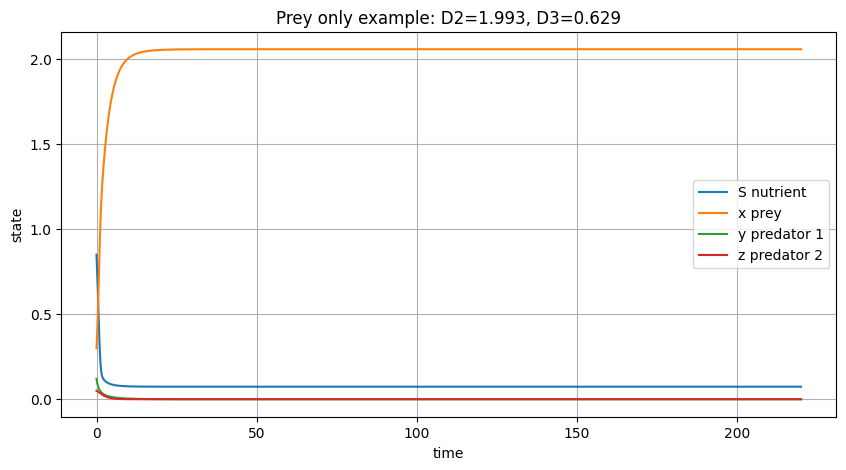

saved: /home/nguyen-tri/NguyenTri/Code/PrjMM/experiments/figures/removal_rate_phase_diagram/timeseries_2_p2_boundary.png


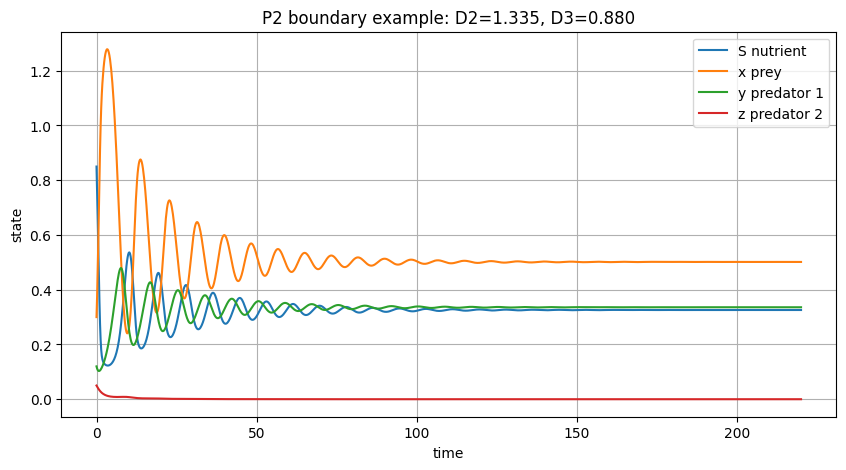

saved: /home/nguyen-tri/NguyenTri/Code/PrjMM/experiments/figures/removal_rate_phase_diagram/timeseries_3_stable_p3.png


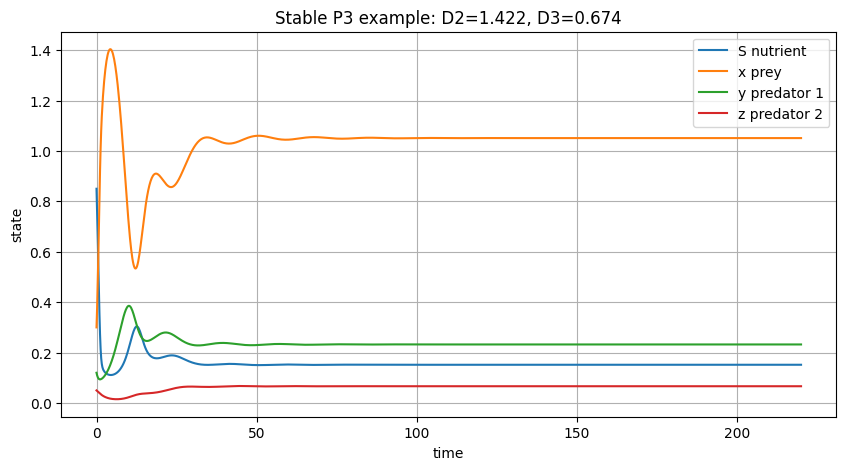

saved: /home/nguyen-tri/NguyenTri/Code/PrjMM/experiments/figures/removal_rate_phase_diagram/timeseries_4_oscillatory_coexistence.png


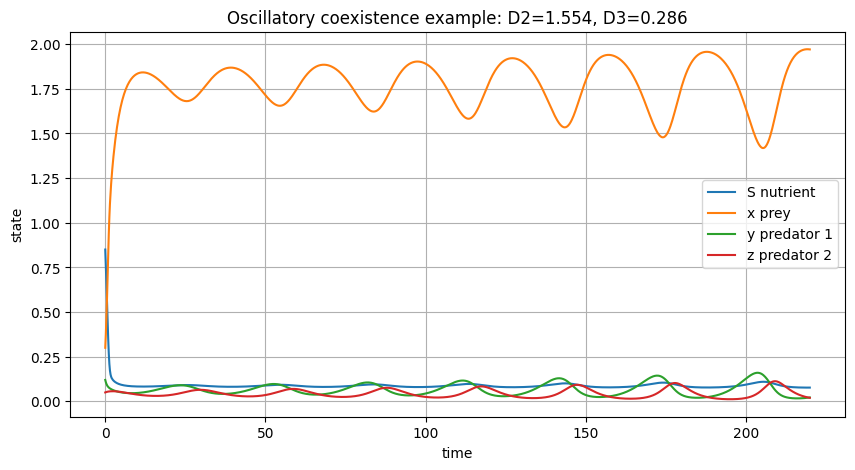

In [6]:
summary_rows = []

def solve_full_trajectory(p, U0=(0.85, 0.30, 0.12, 0.05), T=220.0, transient=120.0):
    t_eval = np.linspace(0, T, 1200)
    sol = solve_ivp(
        lambda t, U: ChemostatModel(p).system(np.maximum(U, 0.0)),
        (0.0, T),
        U0,
        t_eval=t_eval,
        max_step=0.5,
        rtol=1e-6,
        atol=1e-9,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    Y = np.maximum(sol.y, 0.0)
    keep = sol.t >= transient
    regime, means, amps, bio_amp = classify_regime(Y[:, keep])
    return sol.t, Y, regime, means, amps, bio_amp

for regime, D2, D3 in selected:
    p = dict(base_params, D2=float(D2), D3=float(D3))
    t, Y, assigned, means, amps, bio_amp = solve_full_trajectory(p)

    plt.figure(figsize=(10, 5))
    for row, label in zip(Y, ["S nutrient", "x prey", "y predator 1", "z predator 2"]):
        plt.plot(t, row, label=label)
    plt.xlabel("time")
    plt.ylabel("state")
    plt.title(f"{REGIME_LABELS[assigned]} example: D2={D2:.3f}, D3={D3:.3f}")
    plt.legend()
    savefig(f"timeseries_{assigned}_{REGIME_LABELS[assigned].lower().replace(' ', '_')}.png")
    plt.show()

    summary_rows.append({
        "D1": base_params["D1"],
        "D2": D2,
        "D3": D3,
        "mean_S": means[0],
        "mean_x": means[1],
        "mean_y": means[2],
        "mean_z": means[3],
        "oscillation_amplitude": bio_amp,
        "regime": REGIME_LABELS[assigned],
    })

## Summary table


**Code Explanation:**
**Summary Table**: Formats and outputs the collected summary statistics (using Pandas if available) to a CSV file. This table documents the exact parameters and measurements corresponding to the representative dynamics shown in the time-series plots.

In [7]:
try:
    import pandas as pd
    summary_table = pd.DataFrame(summary_rows)
    display(summary_table.round(4))
    summary_table.to_csv(FIG_DIR / "representative_regime_summary.csv", index=False)
    print(f"saved: {FIG_DIR / 'representative_regime_summary.csv'}")
except ImportError:
    for row in summary_rows:
        print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})

,D1,D2,D3,mean_S,mean_x,mean_y,mean_z,oscillation_amplitude,regime
0,0.45,1.9929,0.6286,0.0736,2.0586,0.0000,0.0000,0.0000,Prey only
1,0.45,1.3347,0.8800,0.3259,0.5016,0.3360,0.0000,0.0057,P2 boundary
2,0.45,1.4224,0.6743,0.1518,1.0510,0.2323,0.0666,0.0004,Stable P3
3,0.45,1.5541,0.2857,0.0874,1.7699,0.0658,0.0450,0.5531,Oscillatory coexistence


saved: /home/nguyen-tri/NguyenTri/Code/PrjMM/experiments/figures/removal_rate_phase_diagram/representative_regime_summary.csv


## Report interpretation

- The heatmap shows that changing `D2` and `D3` can move the system between washout, boundary equilibria, stable coexistence, and oscillatory coexistence.
- Large `D2` makes predator 1 harder to sustain, so the system tends to collapse to the prey-only state `P1`.
- Large `D3` makes predator 2 harder to sustain, so the system often moves toward the boundary coexistence state `P2` with `z=0`.
- Regions classified as stable `P3` indicate full coexistence with small long-run amplitude.
- Regions classified as oscillatory coexistence indicate Hopf-like behavior: all species remain positive, but their densities oscillate instead of converging to a fixed equilibrium.
- This experiment supports the paper's modelling point that distinct removal rates destroy the simple conservation-law reduction and make the full 4D dynamics ecologically important.